Journal used to examine and validate the info pulled for each protein.

### Initialization

In [23]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt


# choose file
file_path = "../data/3_organized/protein_info_RV.tsv"
raw_data_dir = "../data/1_raw/rv_proteome/"

# check working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/keitaichii/Programming/RESEARCH/TORII/tardigrade_proteome_KG/notebooks


In [24]:
# convert to DF 
raw_df = pd.read_csv(file_path, sep='\t', dtype=str)

# show first lines of file
print(raw_df.head())

# check unique protein count based on "UniProt_ID" column
unique_proteins = raw_df["UniProt_ID"].nunique()
total_proteins = len(raw_df)
print(f"Total proteins: {total_proteins}, Unique proteins: {unique_proteins}")

   UniProt_ID     NCBI_ID                                           Sequence  \
0  A0A1D1W4Z0  GAV06484.1  MKLLSAVALKVDTAPKPEAPPPAEAAPLPAKIVFVNRVDTYFGRIL...   
1  A0A1D1V1C6  GAU92238.1  MLVANLAFADFGLNFFAFPLFAISSFKTKWVFGQLGCDYYVVSGGF...   
2  A0A1D1VZ53  GAV06675.1  MTFGMHSCLCWMTLTSSVVLCEVNVISASENSKTDPLGENATGWTP...   
3  A0A1D1WBY2  GAV09944.1  MDIPHTILADVFAYFELHFNFYFRRVSQTWRKLLTRTFRNNHLTFN...   
4  A0A1D1VBK5  GAU99031.1  MHHHCCPPPLFGFPCLLLFSTSTYSCMDVLREWFVSAFQVSSMSIC...   

  GeneID                                              GO_mf  \
0    NaN  GO:0019205 - F:nucleobase-containing compound ...   
1    NaN  GO:0009881 - F:photoreceptor activity;GO:00049...   
2    NaN                                                NaN   
3    NaN                                                NaN   
4    NaN  GO:0003910 - F:DNA ligase (ATP) activity;GO:00...   

                                               GO_cc  \
0                                                NaN   
1                           

### GO Terms

In [25]:
# isolate GO-term related columns
go_term_columns = [col for col in raw_df.columns if 'GO:' in str(raw_df[col].dropna().astype(str).values).upper()]
# make a new DF with only GO-term columns
go_df = raw_df[go_term_columns]
# show first lines of GO-term DF
print(go_df.head())
# count number of rows total
print(f"Total number of rows: {len(go_df)}")

                                               GO_mf  \
0  GO:0019205 - F:nucleobase-containing compound ...   
1  GO:0009881 - F:photoreceptor activity;GO:00049...   
2                                                NaN   
3                                                NaN   
4  GO:0003910 - F:DNA ligase (ATP) activity;GO:00...   

                                               GO_cc  \
0                                                NaN   
1                            GO:0016020 - C:membrane   
2                            GO:0016020 - C:membrane   
3                                                NaN   
4  GO:0032807 - C:DNA ligase IV complex;GO:000595...   

                                               GO_bp  
0  GO:0006139 - P:nucleobase-containing compound ...  
1  GO:0007601 - P:visual perception;GO:0007602 - ...  
2                                                NaN  
3                                                NaN  
4  GO:0006303 - P:double-strand break repair via ..

In [26]:
# count the number of NaN entries in each GO-term column
go_mf_nan_counts = 0
go_cc_nan_counts = 0
go_bp_nan_counts = 0
all_go_nan_counts = 0

for idx, row in go_df.iterrows():
    curr_row = 0
    for col in go_term_columns:
        if 'GO_mf' in col and pd.isna(row[col]):
            go_mf_nan_counts += 1
            curr_row += 1
        elif 'GO_cc' in col and pd.isna(row[col]):
            go_cc_nan_counts += 1
            curr_row += 1
        elif 'GO_bp' in col and pd.isna(row[col]):
            go_bp_nan_counts += 1
            curr_row += 1
    if curr_row == 3:
        all_go_nan_counts += 1


# present results as raw value and percentage
total_rows = len(go_df)
print(f"GO Term NaN Counts out of {total_rows} proteins:")
print(f"    GO Molecular Function NaN count: {go_mf_nan_counts} ({(go_mf_nan_counts / total_rows) * 100:.2f}%)")
print(f"    GO Cellular Component NaN count: {go_cc_nan_counts} ({(go_cc_nan_counts / total_rows) * 100:.2f}%)")
print(f"    GO Biological Process NaN count: {go_bp_nan_counts} ({(go_bp_nan_counts / total_rows) * 100:.2f}%)")
print(f"    GO terms with NaN in all three categories: {all_go_nan_counts} ({(all_go_nan_counts / total_rows) * 100:.2f}%)")

GO Term NaN Counts out of 22416 proteins:
    GO Molecular Function NaN count: 13526 (60.34%)
    GO Cellular Component NaN count: 12294 (54.84%)
    GO Biological Process NaN count: 15603 (69.61%)
    GO terms with NaN in all three categories: 10217 (45.58%)


In [27]:
# distribution of which GO terms are most/least common in each category
def isolate_go_term_id(go_cell_string):
    go_cell_string = str(go_cell_string)
    # split by ;
    go_term_ids = go_cell_string.split(';')
    # take only the GO term IDs (first 7 characters)
    # go_term_ids = [term.strip()[:10] for term in go_terms if term.strip().startswith('GO:')]
    return go_term_ids

go_mf_dict = {}
go_cc_dict = {}
go_bp_dict = {}

for idx, row in go_df.iterrows():
    for col in go_term_columns:
        if not pd.isna(row[col]):
            go_term_ids = isolate_go_term_id(row[col])
            if 'GO_mf' in col:
                for go_id in go_term_ids:
                    if go_id in go_mf_dict:
                        go_mf_dict[go_id] += 1
                    else:
                        go_mf_dict[go_id] = 1
            elif 'GO_cc' in col:
                for go_id in go_term_ids:
                    if go_id in go_cc_dict:
                        go_cc_dict[go_id] += 1
                    else:
                        go_cc_dict[go_id] = 1
            elif 'GO_bp' in col:
                for go_id in go_term_ids:
                    if go_id in go_bp_dict:
                        go_bp_dict[go_id] += 1
                    else:
                        go_bp_dict[go_id] = 1

# show top 10 most common GO terms in each category
print("\nTop 5 most common GO Molecular Function terms:")
for go_id, count in sorted(go_mf_dict.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"    {go_id}: {count} occurrences")
print("\nTop 5 most common GO Cellular Component terms:")
for go_id, count in sorted(go_cc_dict.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"    {go_id}: {count} occurrences")
print("\nTop 5 most common GO Biological Process terms:")
for go_id, count in sorted(go_bp_dict.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"    {go_id}: {count} occurrences")


Top 5 most common GO Molecular Function terms:
    GO:0005524 - F:ATP binding: 992 occurrences
    GO:0008270 - F:zinc ion binding: 772 occurrences
    GO:0046872 - F:metal ion binding: 731 occurrences
    GO:0003677 - F:DNA binding: 459 occurrences
    GO:0003723 - F:RNA binding: 370 occurrences

Top 5 most common GO Cellular Component terms:
    GO:0016020 - C:membrane: 2742 occurrences
    GO:0005634 - C:nucleus: 1756 occurrences
    GO:0005737 - C:cytoplasm: 1263 occurrences
    GO:0005886 - C:plasma membrane: 1186 occurrences
    GO:0005829 - C:cytosol: 466 occurrences

Top 5 most common GO Biological Process terms:
    GO:0006508 - P:proteolysis: 347 occurrences
    GO:0035556 - P:intracellular signal transduction: 169 occurrences
    GO:0007168 - P:receptor guanylyl cyclase signaling pathway: 131 occurrences
    GO:0015031 - P:protein transport: 131 occurrences
    GO:0007165 - P:signal transduction: 122 occurrences


In [28]:
# get sample statistics for the GO-term occurences: average, median, std
def compute_go_term_stats(go_dict):
    counts = list(go_dict.values())
    average = sum(counts) / len(counts) if counts else 0
    median = sorted(counts)[len(counts) // 2] if counts else 0
    std_dev = (sum((x - average) ** 2 for x in counts) / len(counts)) ** 0.5 if counts else 0
    return average, median, std_dev

# output
mf_avg, mf_median, mf_std = compute_go_term_stats(go_mf_dict)
cc_avg, cc_median, cc_std = compute_go_term_stats(go_cc_dict)
bp_avg, bp_median, bp_std = compute_go_term_stats(go_bp_dict)

print("\nGO Term Occurrence Statistics:")
print(f"    GO Molecular Function - Average: {mf_avg:.2f}, Median: {mf_median}, Std Dev: {mf_std:.2f}")
print(f"    GO Cellular Component - Average: {cc_avg:.2f}, Median: {cc_median}, Std Dev: {cc_std:.2f}")
print(f"    GO Biological Process - Average: {bp_avg:.2f}, Median: {bp_median}, Std Dev: {bp_std:.2f}")


GO Term Occurrence Statistics:
    GO Molecular Function - Average: 9.23, Median: 2, Std Dev: 43.26
    GO Cellular Component - Average: 18.44, Median: 3, Std Dev: 133.90
    GO Biological Process - Average: 5.72, Median: 2, Std Dev: 13.61


In [29]:
def make_plot_of_go_counts(go_dict, category_name, top_x=10):
    # sort and plot only top X
    go_dict = dict(sorted(go_dict.items(), key=lambda item: item[1], reverse=True)[:top_x])
    go_ids = list(go_dict.keys())
    counts = list(go_dict.values())

    plt.figure(figsize=(10, 6))
    plt.barh(go_ids, counts, color='skyblue')
    plt.xlabel('Number of Occurrences')
    plt.title(f'GO Term Occurrences in {category_name}')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest counts on top
    plt.tight_layout()
    plt.show()


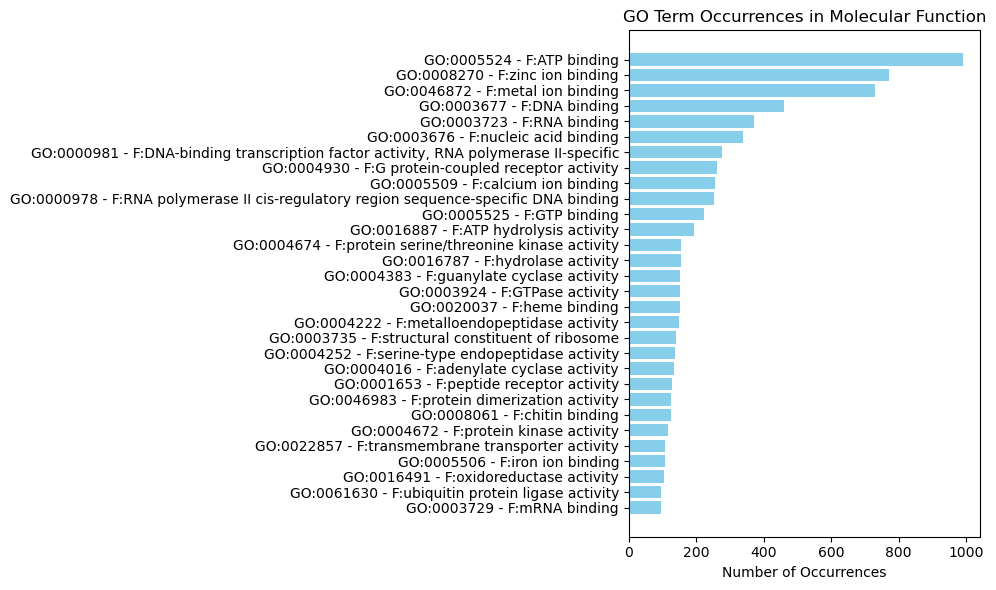

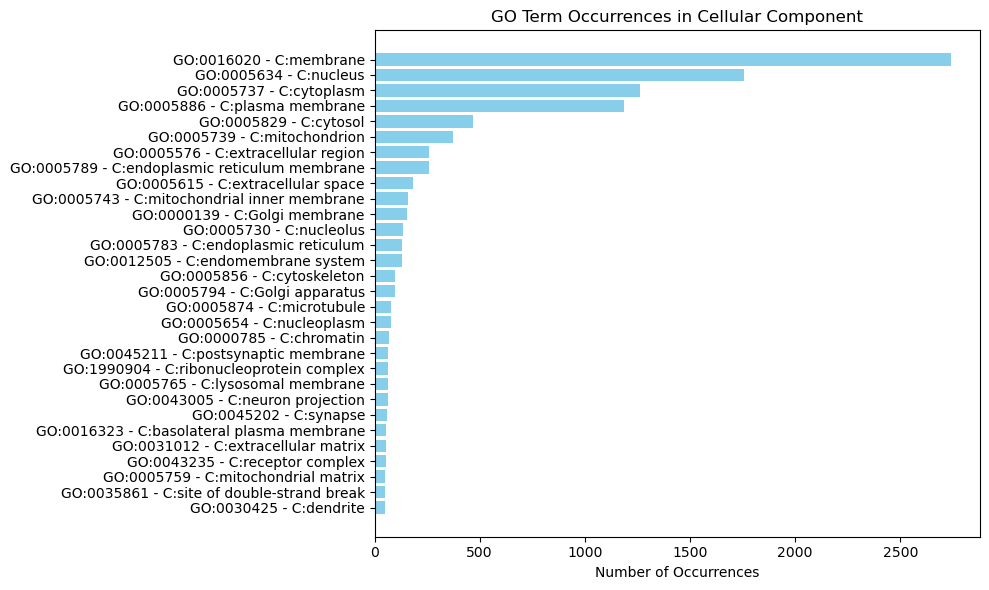

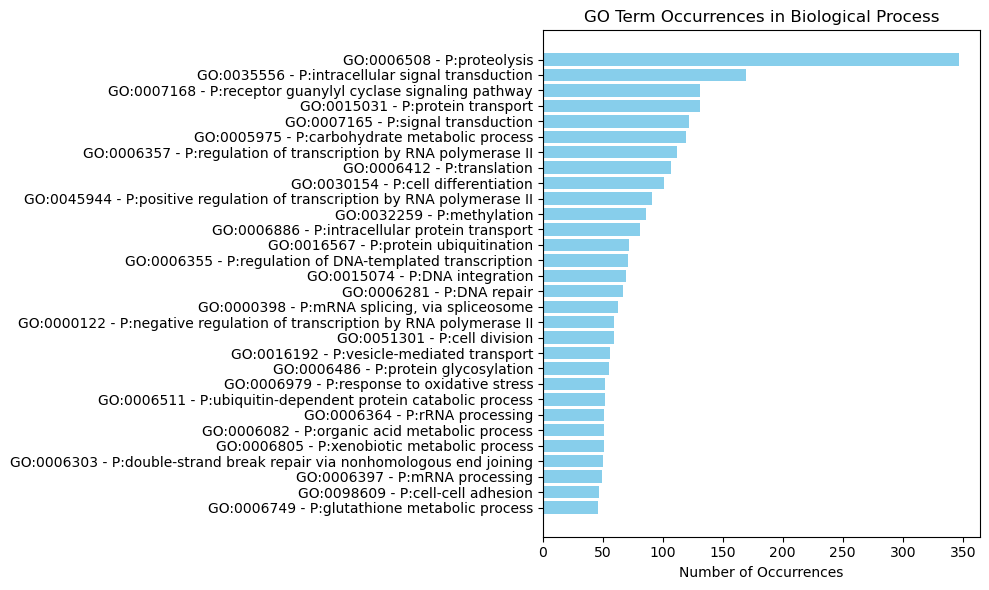

In [34]:
# plot top GO terms in each category
make_plot_of_go_counts(go_mf_dict, 'Molecular Function', top_x=30)
make_plot_of_go_counts(go_cc_dict, 'Cellular Component', top_x=30)
make_plot_of_go_counts(go_bp_dict, 'Biological Process', top_x=30)

In [31]:
# get a range for the number of GO terms per protein
go_term_counts = []
for idx, row in go_df.iterrows():
    count = 0
    for col in go_term_columns:
        if not pd.isna(row[col]):
            go_term_ids = isolate_go_term_id(row[col])
            count += len(go_term_ids)
    go_term_counts.append(count)

# output basic stats
average_go_terms = sum(go_term_counts) / len(go_term_counts)
median_go_terms = sorted(go_term_counts)[len(go_term_counts) // 2]
top_counts_of_go_terms = sorted(go_term_counts, reverse=True)[:5]
print(f"\nGO Terms per Protein Statistics:")
print(f"    Average number of GO terms per protein: {average_go_terms:.2f}")
print(f"    Median number of GO terms per protein: {median_go_terms}")
print(f"    Top 5 counts of GO terms per protein: {top_counts_of_go_terms}")


GO Terms per Protein Statistics:
    Average number of GO terms per protein: 1.89
    Median number of GO terms per protein: 1
    Top 5 counts of GO terms per protein: [17, 17, 16, 16, 16]


### PFAM, KEGG, PROSITE

In [32]:
# count the number of proteins with na in pfam, kegg, and prosite columns
pfam_nan_count = raw_df['Pfam_domains'].isna().sum()
kegg_nan_count = raw_df['KEGG_pathways'].isna().sum()
prosite_nan_count = raw_df['PROSITE_annotations'].isna().sum()

# output
print(f"\nNumber of proteins with NaN in Pfam_domains: {pfam_nan_count} ({(pfam_nan_count / total_rows) * 100:.2f}%)")
print(f"Number of proteins with NaN in KEGG_pathways: {kegg_nan_count} ({(kegg_nan_count / total_rows) * 100:.2f}%)")
print(f"Number of proteins with NaN in PROSITE_annotations: {prosite_nan_count} ({(prosite_nan_count / total_rows) * 100:.2f}%)")


Number of proteins with NaN in Pfam_domains: 11165 (49.81%)
Number of proteins with NaN in KEGG_pathways: 22416 (100.00%)
Number of proteins with NaN in PROSITE_annotations: 15600 (69.59%)


### Global NA Proteins

In [33]:
# count the number of proteins with NA in every column after col index 3
na_all_proteins = []
na_all_count = 0
for idx, row in raw_df.iterrows():
    if row[3:].isna().all():
        na_all_count += 1
        na_all_proteins.append(row['UniProt_ID'])

# output
print(f"\nNumber of proteins with NaN in all annotation columns after index 3: {na_all_count} ({(na_all_count / total_rows) * 100:.2f}%)\n")

# list
print("List of proteins with NaN in all annotation columns after index 3:")
print(na_all_proteins)  


Number of proteins with NaN in all annotation columns after index 3: 49 (0.22%)

List of proteins with NaN in all annotation columns after index 3:
['A0A1D1V8J4', 'A0A1D1VP54', 'A0A1D1VEC2', 'A0A1D1VTL9', 'A0A1D1VNK8', 'A0A1D1UKQ3', 'A0A1D1VZE7', 'A0A1D1W220', 'A0A1D1W9N4', 'A0A1D1WAC7', 'A0A1D1VNG7', 'A0A1D1UT66', 'A0A1D1W552', 'A0A1D1W4J8', 'A0A1D1W0H8', 'A0A1D1VAR1', 'A0A1D1VYW0', 'A0A1D1VUA6', 'A0A1D1W429', 'A0A1D1W3G8', 'A0A1D1UMI2', 'A0A1D1V4A9', 'A0A1D1W176', 'A0A1D1VWP2', 'A0A1D1W8D6', 'A0A1D1VJB1', 'A0A1D1UWR0', 'A0A1D1VCB9', 'A0A1D1V6R7', 'A0A1D1W1D9', 'A0A1D1VRC2', 'A0A1D1VSR3', 'A0A1D1UP02', 'A0A1D1WAA7', 'A0A1D1V635', 'A0A1D1UBX2', 'A0A1D1VBQ4', 'A0A1D1VUF8', 'A0A1D1UQS5', 'A0A1D1W956', 'A0A1D1UK89', 'A0A1D1UHT8', 'A0A1D1UGR6', 'A0A1D1UD03', 'A0A1D1W384', 'A0A1D1VRH5', 'A0A1D1UH25', 'A0A1D1W1V0', 'A0A1D1UT49']
